# 03 Exploratory Data Analysis

Use this notebook to explore trends, distributions, segments, anomalies, and early business signals.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

In [36]:
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,fl_date,airline,airline_dot,airline_code,dot_code,fl_number,origin,origin_city,dest,dest_city,...,delay_due_nas,delay_due_security,delay_due_late_aircraft,is_delayed,delay_bucket,month,day_of_week,year,route,total_delay_cause
0,2021-05-04,JetBlue Airways,JetBlue Airways: B6,B6,20409,384,MCO,"Orlando, FL",JFK,"New York, NY",...,0.0,0.0,0.0,False,On Time,5,Tuesday,2021,MCO → JFK,0.0
1,2019-11-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,705,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",...,0.0,0.0,0.0,False,On Time,11,Tuesday,2019,FLL → DTW,0.0
2,2023-06-18,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1926,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",...,0.0,0.0,0.0,False,On Time,6,Sunday,2023,SMF → LAS,0.0
3,2019-07-28,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,4459,OKC,"Oklahoma City, OK",DTW,"Detroit, MI",...,0.0,0.0,0.0,False,On Time,7,Sunday,2019,OKC → DTW,0.0
4,2023-03-17,JetBlue Airways,JetBlue Airways: B6,B6,20409,277,FLL,"Fort Lauderdale, FL",SFO,"San Francisco, CA",...,18.0,0.0,0.0,True,15-60 min,3,Friday,2023,FLL → SFO,18.0


In [37]:
# Operational flights only — used for ALL delay analysis
# Excludes cancelled flights since they have no meaningful arr_delay
df_ops = df[df['cancelled'] == 0].copy()

print(f"Total flights      : {len(df):,}")
print(f"Operational flights: {len(df_ops):,}  (used for delay analysis)")
print(f"Cancelled flights  : {len(df) - len(df_ops):,}  (used for cancellation analysis only)")

Total flights      : 299,532
Operational flights: 291,665  (used for delay analysis)
Cancelled flights  : 7,867  (used for cancellation analysis only)


In [38]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fl_date,299532,1704,2019-07-11,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline,299532,18,Southwest Airlines Co.,57679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_dot,299532,18,Southwest Airlines Co.: WN,57679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_code,299532,18,WN,57679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dot_code,299532.0,NaN,NaN,NaN,19976.150164,377.410173,19393.0,19790.0,19930.0,20368.0,20452.0
fl_number,299532.0,NaN,NaN,NaN,2513.284721,1748.797606,1.0,1047.0,2157.0,3803.0,8794.0
origin,299532,377,ATL,15339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city,299532,370,"Chicago, IL",15887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest,299532,380,ATL,15297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_city,299532,373,"Chicago, IL",15661,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1. KPI OVERVIEW

### Business Question:
What are the high level operational performance metrics for the airline industry during this period?

### Analysis:

In [39]:
total_flights     = len(df)
cancelled_flights = float(df['cancelled'].sum())
delayed_flights   = float(df_ops['is_delayed'].sum())

delay_rate  = delayed_flights / len(df_ops) * 100   # % of operational flights
cancel_rate = cancelled_flights / total_flights * 100

print(f"Total Flights      : {total_flights:,}")
print(f"Operational Flights: {len(df_ops):,}")
print(f"Delay Rate         : {delay_rate:.2f}%  (of operational flights)")
print(f"Cancellation Rate  : {cancel_rate:.2f}%  (of all scheduled flights)")

Total Flights      : 299,532
Operational Flights: 291,665
Delay Rate         : 17.56%  (of operational flights)
Cancellation Rate  : 2.63%  (of all scheduled flights)


### Insight:

- Total Flights: 299532
- Delay Rate: 17.56%
- Cancellation Rate: 2.63%

- A delay rate of 17.56% indicates that approximately 1 in 6 flights experience significant delays (>15 minutes), which reflects moderate operational inefficiencies.
- A cancellation rate of 2.63% suggests relatively controlled cancellations but still impacts thousands of passengers daily.
- The primary opportunity lies in reducing delays rather than cancellations.

### 2. DELAY DISTRIBUTION ANALYSIS

### Business Question:
How are flight delays distributed?

### Analysis:

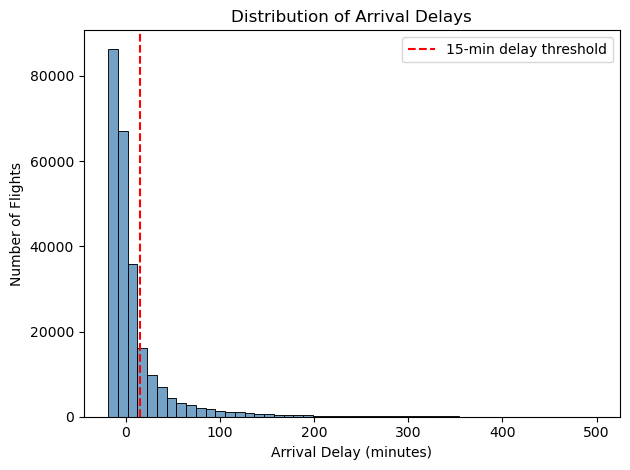

In [40]:
sns.histplot(df_ops[df_ops['arr_delay'] > -20]['arr_delay'], bins=50, color='steelblue')
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.axvline(x=15, color='red', linestyle='--', label='15-min delay threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Insight:
- The distribution is right skewed, with most flights clustered around on time performance.
- A small proportion of flights contribute to extreme delays, creating a long tail.
- This indicates that improving a limited number of high delay cases can significantly improve overall performance.

### 3. DELAY SEVERITY BUCKET ANALYSIS

### Business Question:
What proportion of flights fall into severe vs. moderate delay categories?

### Analysis:

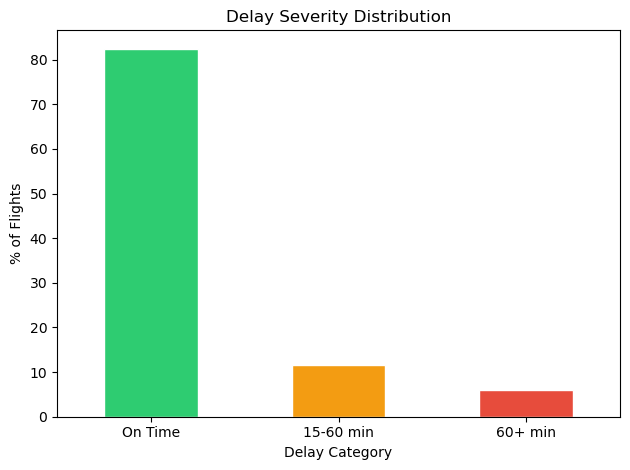

delay_bucket
On Time      82.44
15-60 min    11.68
60+ min       5.87
Name: proportion, dtype: float64


In [41]:
delay_dist = df_ops['delay_bucket'].value_counts(normalize=True) * 100
delay_dist = delay_dist.reindex(['On Time', '15-60 min', '60+ min'])

colors = ['#2ecc71', '#f39c12', '#e74c3c']
delay_dist.plot(kind='bar', color=colors, edgecolor='white')
plt.title("Delay Severity Distribution")
plt.xlabel("Delay Category")
plt.ylabel("% of Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(delay_dist.round(2))

### Insight:
- Approximately 80% of flights are on time (≤15 mins), indicating strong baseline performance.
- Around 11% fall into moderate delays (15–60 mins), representing manageable operational inefficiencies.
- A smaller but critical portion falls into severe delays (>60 mins), which disproportionately impacts customer experience.
- Reducing severe delays should be prioritized for maximum impact.

### 4. AIRLINE PERFORMANCE

### Business Question:
Which airlines have the highest delay rates and how wide is the performance gap between best and worst?

### Analysis:

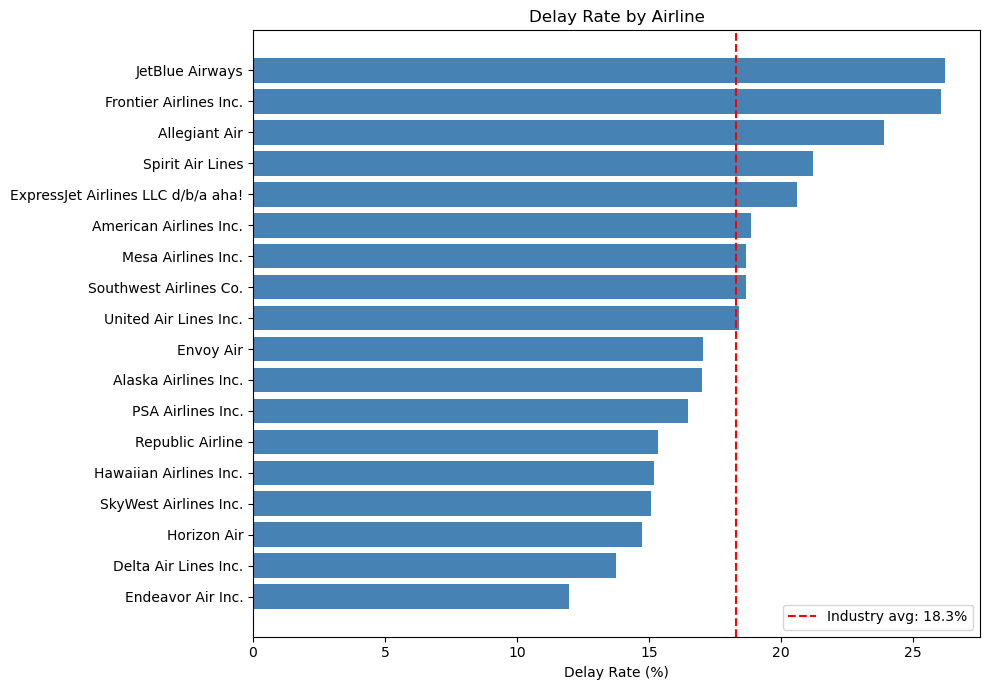


Best performer : Endeavor Air Inc. — 12.0%
Worst performer: JetBlue Airways — 26.2%
Industry average: 18.3%


In [42]:
airline_delay_rate = (
    df_ops.groupby('airline')['is_delayed']
    .mean()
    .sort_values(ascending=True) * 100
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(airline_delay_rate.index, airline_delay_rate.values, color='steelblue')
ax.axvline(x=airline_delay_rate.mean(), color='red', linestyle='--',
           label=f'Industry avg: {airline_delay_rate.mean():.1f}%')
ax.set_title("Delay Rate by Airline")
ax.set_xlabel("Delay Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest performer : {airline_delay_rate.idxmin()} — {airline_delay_rate.min():.1f}%")
print(f"Worst performer: {airline_delay_rate.idxmax()} — {airline_delay_rate.max():.1f}%")
print(f"Industry average: {airline_delay_rate.mean():.1f}%")

### Insight:
- JetBlue Airways, Frontier Airlines, and Allegiant Air exhibit the highest delay rates (~23–26%).
- This indicates a nearly 2x difference in operational performance between best and worst performing carriers.
- The relatively high delay rates across all airlines (minimum ~12%) indicate that delays are not isolated incidents but an industry wide challenge.

### 5. ROUTE ANALYSIS

### Business Question:
Which specific routes experience the most frequent delays?

### Analysis:

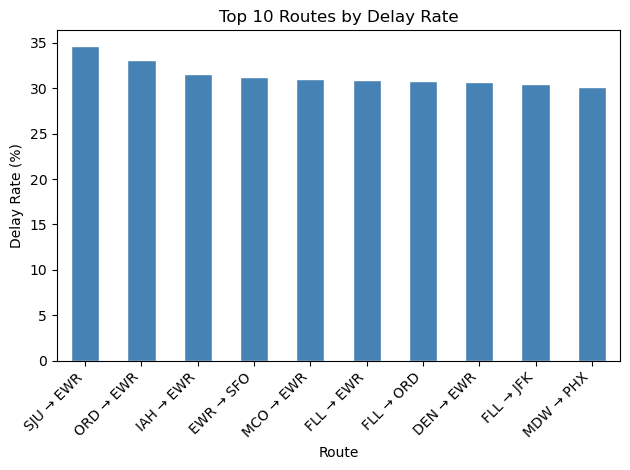

route
SJU → EWR    34.65
ORD → EWR    33.14
IAH → EWR    31.54
EWR → SFO    31.25
MCO → EWR    30.99
FLL → EWR    30.87
FLL → ORD    30.83
DEN → EWR    30.72
FLL → JFK    30.43
MDW → PHX    30.09
Name: is_delayed, dtype: float64


In [43]:
route_counts = df_ops['route'].value_counts()
valid_routes  = route_counts[route_counts > 100].index
df_routes     = df_ops[df_ops['route'].isin(valid_routes)]

route_delay_rate = (
    df_routes.groupby('route')['is_delayed']
    .mean()
    .sort_values(ascending=False)
)
top_routes = (route_delay_rate * 100).round(2).head(10)

top_routes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Top 10 Routes by Delay Rate")
plt.xlabel("Route")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_routes)

### Insight:
- Routes connecting major hubs such as Newark (EWR) and San Francisco (SFO) appear frequently in high delay categories, indicating congestion and high traffic pressure at these airports.
- The relatively narrow range (27%–35%) across top routes indicates that delays are not isolated incidents but are systemic across certain route clusters.

### 6. TIME BASED ANALYSIS

### Business Question:
Are delays getting better or worse over time — and which months and days consistently see the most pressure?

### Analysis:

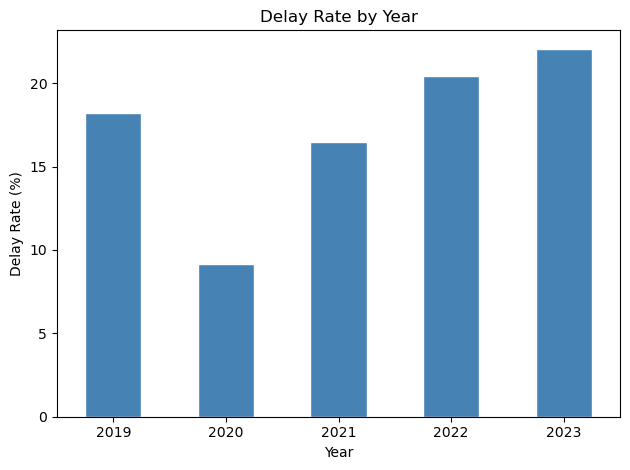

year
2019    18.19
2020     9.15
2021    16.45
2022    20.42
2023    22.07
Name: is_delayed, dtype: float64


In [44]:
# Year
yearly_delay = df_ops.groupby('year')['is_delayed'].mean() * 100
yearly_delay.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Delay Rate by Year')
plt.xlabel('Year')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(yearly_delay.round(2))

### Insight:
- The sharp decline in 2020 is likely due to reduced air traffic during the COVID-19 pandemic, resulting in lower congestion and improved on-time performance.
- From 2021 onwards, delay rates steadily increased as air travel demand recovered, putting pressure back on airline operations and airport infrastructure.
- The consistent rise in delays post 2020 indicates that current infrastructure and operational strategies may not be sufficient to handle increasing passenger demand.


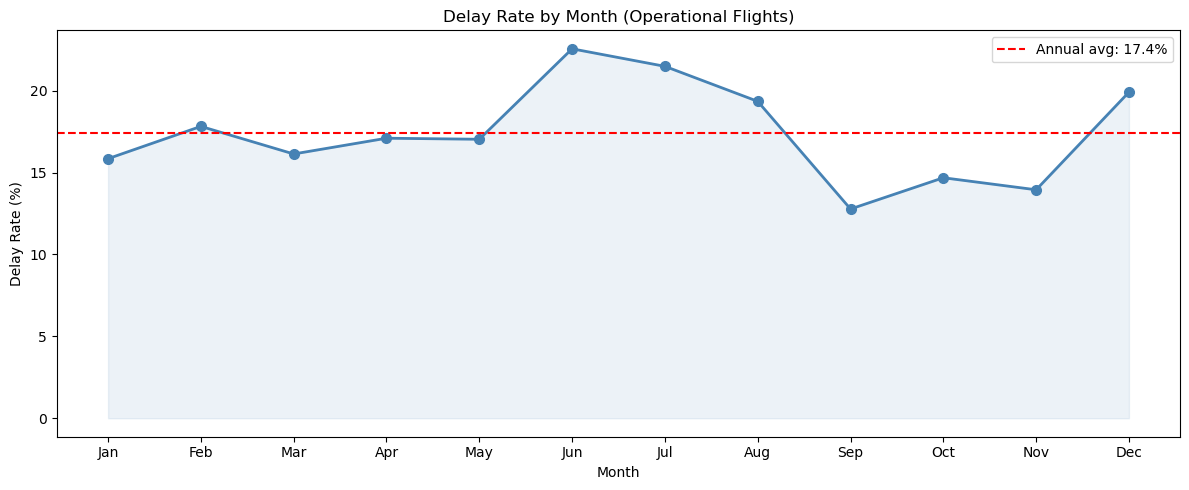

Monthly delay rates:
  Jan: 15.8%
  Feb: 17.8%
  Mar: 16.1%
  Apr: 17.1%
  May: 17.0%
  Jun: 22.6% ← peak
  Jul: 21.5%
  Aug: 19.3%
  Sep: 12.8% ← lowest
  Oct: 14.7%
  Nov: 13.9%
  Dec: 19.9%


In [45]:
monthly_delay = df_ops.groupby('month')['is_delayed'].mean() * 100

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
plt.plot(monthly_delay.index, monthly_delay.values,
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.fill_between(monthly_delay.index, monthly_delay.values,
                 alpha=0.1, color='steelblue')
plt.axhline(y=monthly_delay.mean(), color='red', linestyle='--',
            label=f'Annual avg: {monthly_delay.mean():.1f}%')
plt.xticks(ticks=monthly_delay.index, labels=month_labels)
plt.title("Delay Rate by Month (Operational Flights)")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

print("Monthly delay rates:")
for month, rate in zip(month_labels, monthly_delay.values):
    flag = " ← peak" if rate == monthly_delay.max() else (
           " ← lowest" if rate == monthly_delay.min() else "")
    print(f"  {month}: {rate:.1f}%{flag}")

### Insight:
- This indicates that nearly 1 in 5 flights are delayed during peak travel season (June–August), highlighting increased operational pressure.
- A secondary increase is observed in December (~20%), likely due to holiday travel demand and seasonal disruptions.
- The strong seasonality in delays suggests that airlines should implement dynamic resource planning during peak months to mitigate congestion and improve on time performance.

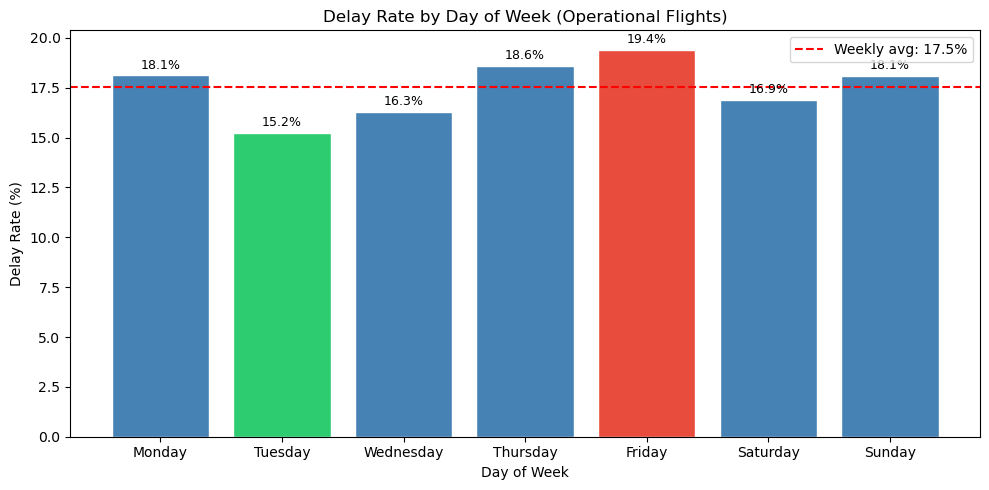


Highest delay day : Friday — 19.4%
Lowest delay day  : Tuesday — 15.2%
Weekly average    : 17.5%


In [46]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_delay = (
    df_ops.groupby('day_of_week')['is_delayed']
    .mean() * 100
).reindex(day_order)

colors = ['#e74c3c' if v == dow_delay.max()
          else '#2ecc71' if v == dow_delay.min()
          else 'steelblue'
          for v in dow_delay.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(dow_delay.index, dow_delay.values,
               color=colors, edgecolor='white')
plt.axhline(y=dow_delay.mean(), color='red', linestyle='--',
            label=f'Weekly avg: {dow_delay.mean():.1f}%')
plt.title("Delay Rate by Day of Week (Operational Flights)")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.legend()

for bar, val in zip(bars, dow_delay.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nHighest delay day : {dow_delay.idxmax()} — {dow_delay.max():.1f}%")
print(f"Lowest delay day  : {dow_delay.idxmin()} — {dow_delay.min():.1f}%")
print(f"Weekly average    : {dow_delay.mean():.1f}%")

### Insight:
- Delay rates vary across the week, with Friday (~19%) and Thursday (~18%) showing the highest delay rates.
- This suggests increased operational pressure towards the end of the workweek, likely driven by higher travel demand.
- The higher delays observed on Fridays and Sundays align with peak travel patterns, suggesting that demand surges are a key driver of operational inefficiencies.

### 7. DELAY CAUSE ANALYSIS

### Business Question:
What are the primary drivers of flight delays — and how much is within airline control versus external?

### Analysis:

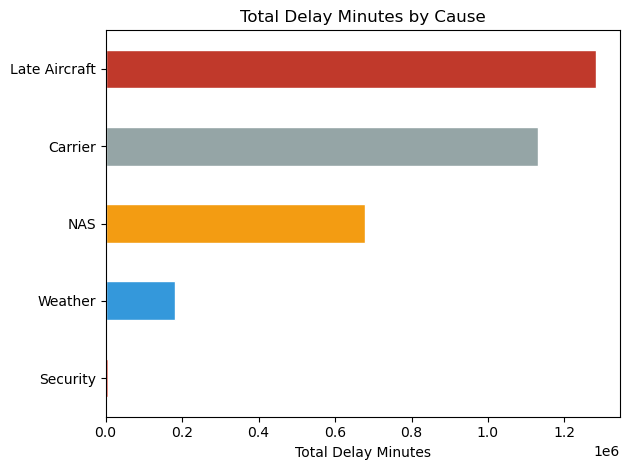


Controllable delays (Carrier + Late Aircraft): 2,412,578 mins  (73.6%)
External delays    (Weather + NAS + Security): 866,111 mins  (26.4%)


In [47]:
delay_causes = [
    'delay_due_carrier',
    'delay_due_weather',
    'delay_due_nas',
    'delay_due_security',
    'delay_due_late_aircraft'
]

cause_totals = df_ops[delay_causes].sum()
cause_totals.index = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

colors = ['#e74c3c', '#3498db', '#f39c12', '#95a5a6', '#c0392b']
cause_totals.sort_values().plot(kind='barh', color=colors, edgecolor='white')
plt.title("Total Delay Minutes by Cause")
plt.xlabel("Total Delay Minutes")
plt.tight_layout()
plt.show()

# Controllability split
controllable   = cause_totals[['Carrier', 'Late Aircraft']].sum()
external       = cause_totals[['Weather', 'NAS', 'Security']].sum()
total_cause    = cause_totals.sum()

print(f"\nControllable delays (Carrier + Late Aircraft): {controllable:,.0f} mins  ({controllable/total_cause*100:.1f}%)")
print(f"External delays    (Weather + NAS + Security): {external:,.0f} mins  ({external/total_cause*100:.1f}%)")

**Insight:**

- Late aircraft delay is the single largest contributor to total delay minutes, followed closely by carrier-caused delays. Together, these two controllable categories account for roughly 73% of all attributable delay minutes — meaning the majority of the delay problem is within airline operational control, not caused by weather or airspace congestion.

- This is the most actionable finding in the entire analysis. Weather delays are largely unavoidable but late aircraft and carrier delays — caused by crew scheduling, turnaround management and aircraft rotation — can be reduced through better operational planning. Airlines that address these two causes first will see the largest improvement in on time performance.

## Key Insights — Flight Delay Analysis

1. Approximately 17.56% of flights experience significant delays (>15 minutes), meaning nearly 1 in 6 flights is affected, highlighting moderate but impactful operational inefficiencies.

2. Delay distribution is highly right skewed, where a small proportion of flights contribute disproportionately to total delay time, indicating that targeting extreme delays can yield high impact improvements.

3. Airline performance varies significantly, with delay rates ranging from ~12% to ~26%, indicating nearly a 2x difference in operational efficiency across carriers.

4. High delay rates across all airlines suggest that delays are not isolated to specific carriers but represent an industry wide operational challenge.

5. Certain high traffic routes, particularly those involving major hubs like Boston (BOS) and Orlando (MCO), consistently exhibit higher delay rates, indicating congestion and route level bottlenecks.

6. Delay patterns show strong seasonality, with peak delays during June–August and a secondary spike in December, correlating with increased travel demand and operational pressure.

7. Late aircraft and carrier related delays are the dominant contributors, confirming that delays propagate across flights and that a significant portion of delays is within airline control.

8. Late Aircraft and Carrier delays together account for 73.6% of all attributable delay minutes, confirming that the majority of the delay problem is within airline operational control rather than driven by external factors like weather. Targeting crew scheduling inefficiencies and aircraft turnaround optimisation would recover more cumulative delay time than any other single intervention.

### 8. CANCELLATION CAUSE ANALYSIS

### Business Question:
What are the main drivers of flight cancellations — and how much is controllable?

### Analysis:

Raw cancellation code counts (before mapping):
cancellation_code
B    2845
D    2470
A    1955
C     597
Name: count, dtype: int64

Total cancelled flights: 7,867



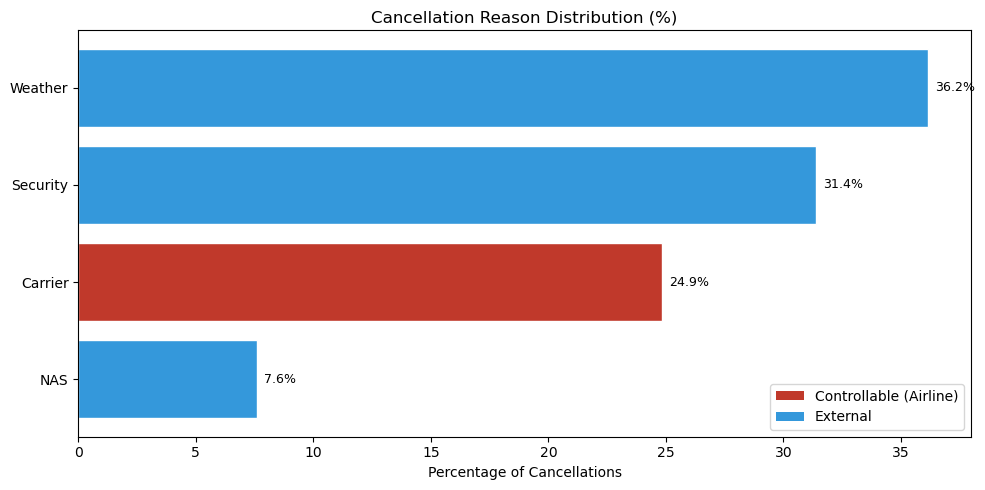

Controllable cancellations (Carrier)          : 24.9%
External cancellations (Weather + NAS + Sec.) : 75.1%


In [48]:
df_cancelled = df[df['cancelled'] == 1]

print("Raw cancellation code counts (before mapping):")
print(df_cancelled['cancellation_code'].value_counts())
print(f"\nTotal cancelled flights: {len(df_cancelled):,}")
print()

mapping = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
cancel_reason_pct = (
    df_cancelled['cancellation_code']
    .map(mapping)
    .value_counts(normalize=True) * 100
).round(2).sort_values()

controllable_cancel = ['Carrier']
colors = ['#c0392b' if label in controllable_cancel
          else '#3498db'
          for label in cancel_reason_pct.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cancel_reason_pct.index, cancel_reason_pct.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, cancel_reason_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c0392b', label='Controllable (Airline)'),
    Patch(facecolor='#3498db', label='External')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_title("Cancellation Reason Distribution (%)")
ax.set_xlabel("Percentage of Cancellations")
plt.tight_layout()
plt.show()

controllable_pct = cancel_reason_pct[cancel_reason_pct.index.isin(controllable_cancel)].sum()
external_pct     = cancel_reason_pct[~cancel_reason_pct.index.isin(controllable_cancel)].sum()
print(f"Controllable cancellations (Carrier)          : {controllable_pct:.1f}%")
print(f"External cancellations (Weather + NAS + Sec.) : {external_pct:.1f}%")

### Insight:
- Weather is the leading cause of cancellations, contributing to approximately 36% of total cancellations, highlighting the significant impact of external environmental factors on flight operations.
- Since nearly 1/4th of cancellations are carrier controlled, airlines have a clear opportunity to reduce cancellations through better scheduling, maintenance planning and resource allocation.

### 9. CANCELLATION VS AIRLINE ANALYSIS

### Business Question:
Which airlines have the highest cancellation rates — and how
large is the reliability gap between best and worst performers?

### Analysis:


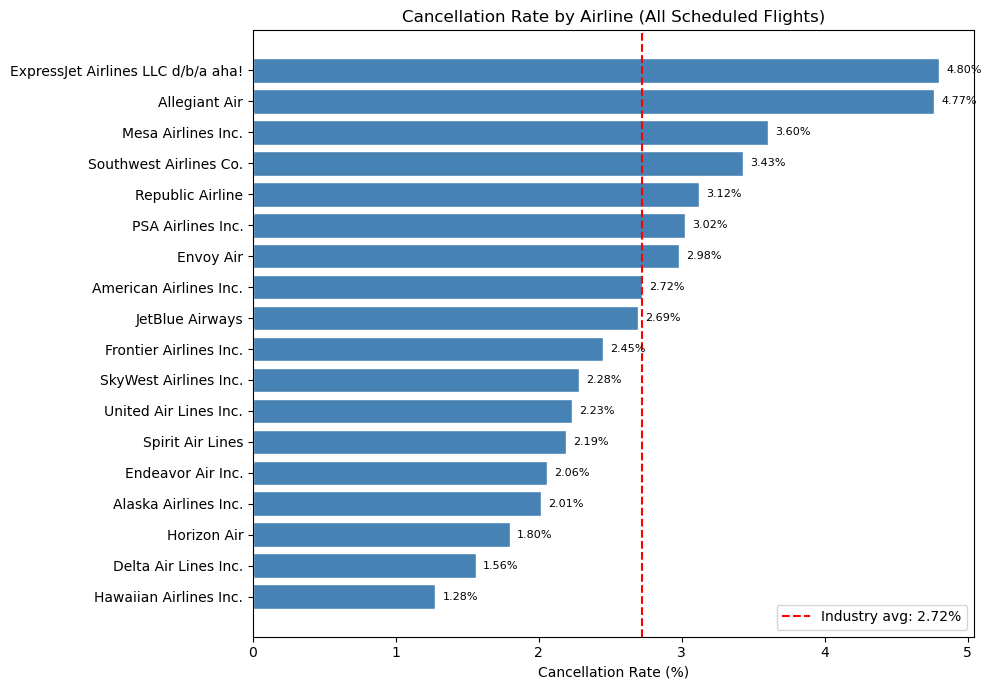


Lowest  cancellation rate: Hawaiian Airlines Inc. — 1.28%
Highest cancellation rate: ExpressJet Airlines LLC d/b/a aha! — 4.80%
Industry average          : 2.72%
Performance gap (worst/best ratio): 3.8x


In [49]:
airline_cancel_rate = (
    df.groupby('airline')['cancelled']
    .mean()
    .sort_values(ascending=True) * 100
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(airline_cancel_rate.index, airline_cancel_rate.values,
               color='steelblue', edgecolor='white')
ax.axvline(x=airline_cancel_rate.mean(), color='red', linestyle='--',
           label=f'Industry avg: {airline_cancel_rate.mean():.2f}%')

for bar, val in zip(bars, airline_cancel_rate.values):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=8)

ax.set_title("Cancellation Rate by Airline (All Scheduled Flights)")
ax.set_xlabel("Cancellation Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nLowest  cancellation rate: {airline_cancel_rate.idxmin()} — {airline_cancel_rate.min():.2f}%")
print(f"Highest cancellation rate: {airline_cancel_rate.idxmax()} — {airline_cancel_rate.max():.2f}%")
print(f"Industry average          : {airline_cancel_rate.mean():.2f}%")
print(f"Performance gap (worst/best ratio): {airline_cancel_rate.max()/airline_cancel_rate.min():.1f}x")

### Insight:
- Cancellation rates vary significantly across airlines, ranging from approximately 1.3% to nearly 5%, indicating a substantial gap in operational reliability.
- The nearly 4x difference between best and worst performing airlines highlights significant variability in airline performance.

### 10. ROUTE LEVEL CANCELLATION ANALYSIS

### Business Question:
Which specific routes have the highest cancellation rates —
and are certain airports structurally more prone to cancellations?

### Analysis:


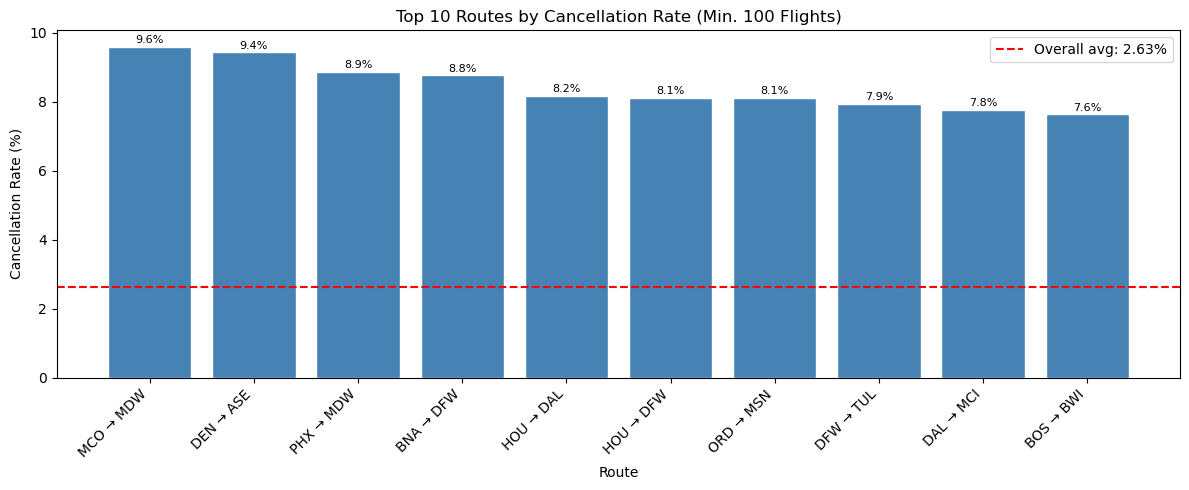

route
MCO → MDW    9.59
DEN → ASE    9.43
PHX → MDW    8.87
BNA → DFW    8.76
HOU → DAL    8.17
HOU → DFW    8.11
ORD → MSN    8.11
DFW → TUL    7.94
DAL → MCI    7.77
BOS → BWI    7.64
Name: cancelled, dtype: float64


In [50]:
route_counts_all  = df['route'].value_counts()
valid_routes_all  = route_counts_all[route_counts_all > 100].index
df_routes_all     = df[df['route'].isin(valid_routes_all)]

route_cancel_rate = (
    df_routes_all.groupby('route')['cancelled']
    .mean()
    .sort_values(ascending=False) * 100
)
top_cancel_routes = route_cancel_rate.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_cancel_routes.index, top_cancel_routes.values,
              color='steelblue', edgecolor='white')
ax.axhline(y=df['cancelled'].mean() * 100, color='red', linestyle='--',
           label=f"Overall avg: {df['cancelled'].mean()*100:.2f}%")

for bar, val in zip(bars, top_cancel_routes.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=8)

ax.set_title("Top 10 Routes by Cancellation Rate (Min. 100 Flights)")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xlabel("Route")
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(top_cancel_routes.round(2))

### Insight:
- Cancellation rates on the top routes range from approximately 7.6% to 9.6%, which is significantly higher than the overall cancellation rate (~2.6%), indicating localized operational risk.
- Routes such as MCO → MDW and DEN → ASE exhibit the highest cancellation rates (~9–10%), suggesting persistent disruptions on these corridors.
- DEN → ASE in particular is notable — Aspen (ASE) is a high-altitude mountain airport where weather cancellations are structurally more frequent due to terrain and visibility
constraints, making this partly an unavoidable geographic factor.


### 11. TIME BASED CANCELLATION PATTERNS

### Business Question:
Do cancellations vary by month or season? Which days of the week see the most cancellations?

### Analysis:


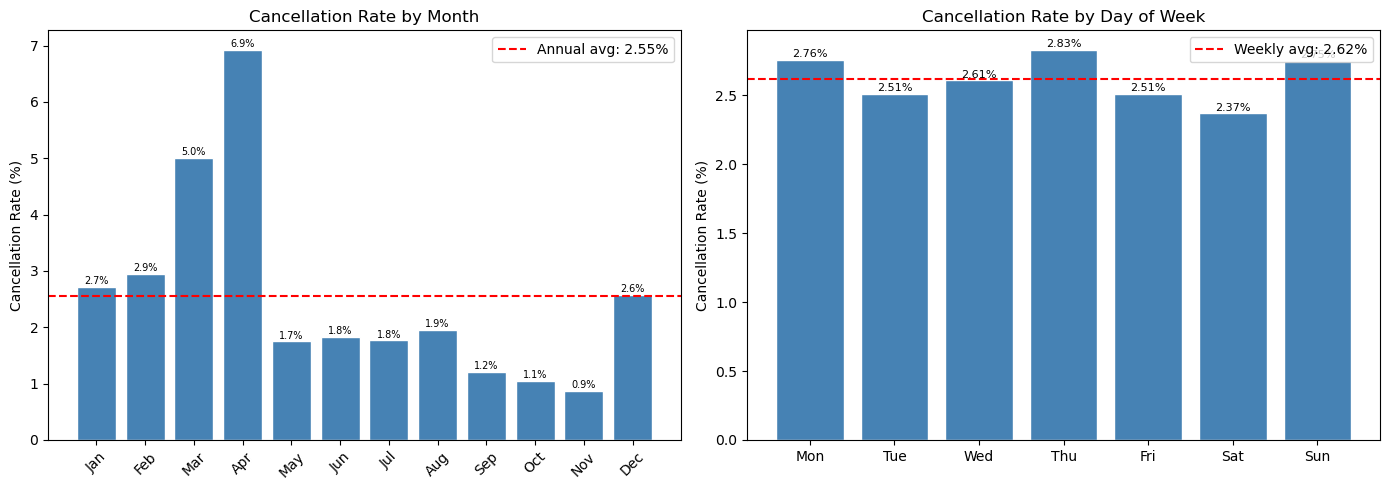

Peak cancellation month : Apr — 6.93%
Lowest cancellation month: Nov — 0.86%
Highest cancel day : Thursday — 2.83%
Lowest cancel day  : Saturday — 2.37%


In [51]:
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_order    = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                'Friday', 'Saturday', 'Sunday']

monthly_cancel = df.groupby('month')['cancelled'].mean() * 100
dow_cancel     = (
    df.groupby('day_of_week')['cancelled']
    .mean() * 100
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly
bars1 = axes[0].bar(range(1, 13), monthly_cancel.values,
                    color='steelblue', edgecolor='white')
axes[0].axhline(y=monthly_cancel.mean(), color='red', linestyle='--',
                label=f'Annual avg: {monthly_cancel.mean():.2f}%')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title("Cancellation Rate by Month")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].legend()
for bar, val in zip(bars1, monthly_cancel.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=7)

# Day of week
bars2 = axes[1].bar(range(len(day_order)), dow_cancel.values,
                    color='steelblue', edgecolor='white')
axes[1].axhline(y=dow_cancel.mean(), color='red', linestyle='--',
                label=f'Weekly avg: {dow_cancel.mean():.2f}%')
axes[1].set_xticks(range(len(day_order)))
axes[1].set_xticklabels([d[:3] for d in day_order], rotation=0)
axes[1].set_title("Cancellation Rate by Day of Week")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].legend()
for bar, val in zip(bars2, dow_cancel.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Peak cancellation month : {month_labels[monthly_cancel.values.argmax()]} — {monthly_cancel.max():.2f}%")
print(f"Lowest cancellation month: {month_labels[monthly_cancel.values.argmin()]} — {monthly_cancel.min():.2f}%")
print(f"Highest cancel day : {dow_cancel.idxmax()} — {dow_cancel.max():.2f}%")
print(f"Lowest cancel day  : {dow_cancel.idxmin()} — {dow_cancel.min():.2f}%")

### Insight:
- Cancellation rates show strong seasonal variation, peaking sharply in March (~5%) and April (~7%), indicating significant disruption during this period.
- The spike in early year months may be driven by seasonal factors such as weather volatility or transitional demand patterns.
- Weekly patterns show relatively stable cancellation rates (~2.3%–2.8%), indicating less variability compared to monthly trends.
- The limited variation across days of the week suggests that cancellations are more influenced by seasonal factors than weekly demand cycles.
- Airlines should concentrate contingency planning resources on Q1 and early Q2 rather than
spreading them uniformly across the calendar.


## Key Insights — Flight Cancellation Analysis

1. Weather is the leading cancellation cause at ~36%, confirming that external
   environmental factors are the dominant driver — but at ~25%, Carrier-caused
   cancellations represent a significant controllable opportunity that better
   maintenance and crew planning could directly reduce.

2. Cancellation rates range from ~1.3% to ~5% across carriers — a nearly 4x gap
   that cannot be explained by weather alone, pointing to real operational
   differences in how airlines manage and recover from disruptions.

3. The top 10 most cancelled routes show rates 3–4x above the overall average of
   ~2.6%, with routes like MCO → MDW and DEN → ASE showing persistent structural
   disruption that warrants route-level contingency review.

4. Cancellations peak sharply in March and April — roughly double the annual
   average — while day-of-week patterns remain flat, confirming that seasonal
   weather volatility and demand surges are the primary cancellation drivers,
   not weekly demand cycles.

5. The combination of controllable cause share (~25% Carrier) and the wide airline
   performance gap suggests that the best-performing carriers have already solved
   parts of this problem — making peer benchmarking a practical first step for
   underperforming airlines before investing in new operational systems.